# Beyond Static DCF: SVR Valuation Pipeline


## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV,learning_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error
from scipy.stats import wilcoxon, ttest_rel
from sklearn.model_selection import TimeSeriesSplit
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs("plots", exist_ok=True)
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({"font.family": "sans-serif", "font.size": 12, "figure.dpi": 100, "savefig.bbox": "tight"})



## Data Loading and Preprocessing

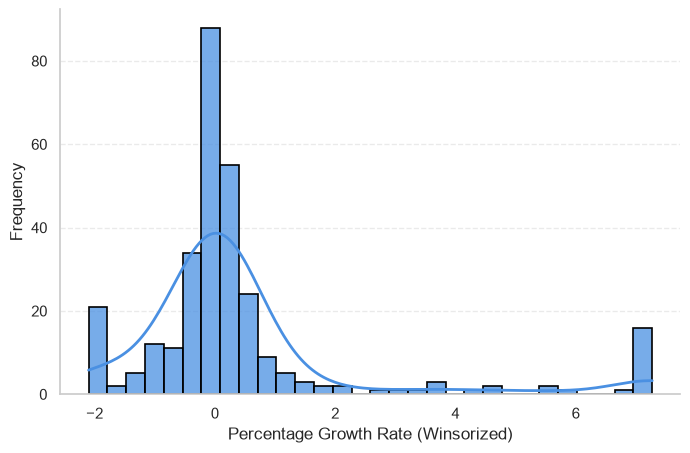

In [2]:
df = pd.read_csv('data/master_ml_dataset.csv').sort_values(by=["Ticker", "Year_Int"]).reset_index(drop=True)

df["FCF_NextYear"] = df.groupby("Ticker")["OperatingCashFlow_Proxy"].shift(-1)
df["Target_FCF_Growth"] = (df["FCF_NextYear"] - df["OperatingCashFlow_Proxy"]) / (df["OperatingCashFlow_Proxy"].abs() + 1)
df = df.dropna(subset=["Target_FCF_Growth"]).copy()

df = df.fillna(0)

features = [
    "Revenue", "Debt_Ratio", "ROA", "Working_Capital", "CapEx",
    "Installed_Capacity_MW", "License_Term_Years",
    "GDP_Growth", "Inflation", "Interest_Rate", 
    "Years_Since_COD", "Pre_Post_COD", "EBIT_Margin"
]

train_df = df[df["Year_Int"] < 2023].copy()
test_df = df[df["Year_Int"] >= 2023].copy()


lower, upper = train_df["Target_FCF_Growth"].quantile(0.05), train_df["Target_FCF_Growth"].quantile(0.95)
train_df["Target_FCF_Growth"] = train_df["Target_FCF_Growth"].clip(lower, upper)

# Sort by Year_Int then Ticker for TimeSeriesSplit
train_df = train_df.sort_values(by=["Year_Int", "Ticker"]).reset_index(drop=True)
test_df = test_df.sort_values(by=["Year_Int", "Ticker"]).reset_index(drop=True)

X_train = train_df[features]
y_train = train_df["Target_FCF_Growth"]
groups_train = train_df["Ticker"]
X_test = test_df[features]
y_test = test_df["Target_FCF_Growth"]


sns.set_theme(style="whitegrid", palette="husl")
plt.figure(figsize=(8, 5)) 
ax = sns.histplot(
    y_train, 
    kde=True, 
    bins=30, 
    color="#4A90E2",          
    edgecolor="black",        
    linewidth=1.2,            
    alpha=0.75,               
    line_kws={"linewidth": 2} 
)

plt.xlabel("Percentage Growth Rate (Winsorized)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)


sns.despine()
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False) 

sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/target_distribution.png", bbox_inches="tight", dpi=600)


## Model Training and Comparison

In [3]:

trad_preds = test_df["OperatingCashFlow_Proxy"]
actual_fcf = test_df["FCF_NextYear"]
trad_mae = mean_absolute_error(actual_fcf, trad_preds)
baseline_errors = np.abs(actual_fcf - trad_preds)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
base_fcf_test = test_df["OperatingCashFlow_Proxy"]

tscv = TimeSeriesSplit(n_splits=3)

def evaluate_model(name, model, param_grid):
    search = RandomizedSearchCV(model, param_grid, n_iter=15, scoring="neg_mean_absolute_error", cv=tscv, n_jobs=-1, random_state=42)
    search.fit(X_train_scaled, y_train)
    best_model = search.best_estimator_
    pred_growth = best_model.predict(X_test_scaled)
    abs_preds = base_fcf_test + (base_fcf_test.abs() + 1) * pred_growth
    mae = mean_absolute_error(actual_fcf, abs_preds)
    results[name] = mae
    return best_model, abs_preds

svr_model, svr_abs_preds = evaluate_model("Support Vector Regression (SVR)", SVR(), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.1, 0.01], "epsilon": [0.01, 0.1, 1]})
xgb_model, _ = evaluate_model("XGBoost", xgb.XGBRegressor(random_state=42), {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 5, 7]})
lgb_model, _ = evaluate_model("LightGBM", LGBMRegressor(random_state=42), {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 5, 7]})
rf_model, _ = evaluate_model("Random Forest", RandomForestRegressor(random_state=42), {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7, None]})
knn_model, _ = evaluate_model("K-Nearest Neighbors", KNeighborsRegressor(), {"n_neighbors": [3, 5, 7, 10, 15], "weights": ["uniform", "distance"]})
ridge_model, _ = evaluate_model("Ridge Regression", Ridge(random_state=42), {"alpha": [0.1, 1, 10, 100, 1000]})

print(f"Traditional Baseline MAE: Rs {trad_mae:,.0f}")
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name} MAE: Rs {mae:,.0f}")

# Model Comparison Plot
names = ["Traditional Baseline"] + list(results.keys())
maes = [trad_mae] + list(results.values())
sorted_indices = np.argsort(maes)
names_sorted = [names[i] for i in sorted_indices]
maes_sorted = [maes[i] for i in sorted_indices]

plt.figure(figsize=(12, 6))
sns.barplot(x=maes_sorted, y=names_sorted, palette="viridis")
plt.xlabel("Mean Absolute Error (Lower is Better)", fontsize=12)
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/model_comparison.png", bbox_inches="tight", dpi=600)
plt.close()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 646
[LightGBM] [Info] Number of data points in the train set: 302, number of used features: 13
[LightGBM] [Info] Start training from score 0.452481
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

## Validation Scatter Plot

In [8]:
# Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(actual_fcf, svr_abs_preds, alpha=0.6, color="#4A90E2")
plt.plot([actual_fcf.min(), actual_fcf.max()], [actual_fcf.min(), actual_fcf.max()], 'r--', lw=2)
plt.xlabel("Actual FCF", fontsize=12)
plt.ylabel("Predicted FCF", fontsize=12)
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/actual_vs_predicted.png", bbox_inches="tight", dpi=600)
plt.close()



## Statistical Significance and Learning Curve

In [9]:
svr_errors = np.abs(actual_fcf - svr_abs_preds)
w_stat, p_w = wilcoxon(baseline_errors, svr_errors)
t_stat, p_t = ttest_rel(baseline_errors, svr_errors)
print(f"Wilcoxon signed-rank test p-value: {p_w:.5f}")
print(f"Paired t-test p-value: {p_t:.5f}")

train_sizes, train_scores, val_scores = learning_curve(
    svr_model, X_train_scaled, y_train,
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5)
)
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#4A90E2", label="Training Error")
plt.plot(train_sizes, val_mean, 'o-', color="#FF5A5F", label="Cross-Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#4A90E2")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="#FF5A5F")
plt.xlabel("Number of Training Firm-Years", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
plt.legend(loc="best")
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/learning_curve.png", bbox_inches="tight", dpi=600)
plt.close()



Wilcoxon signed-rank test p-value: 0.00008
Paired t-test p-value: 0.06222


## Explainable AI (XAI): Permutation Importance and PDP

In [10]:
result = permutation_importance(svr_model, X_train_scaled, y_train, n_repeats=30, random_state=42, n_jobs=-1)
importances_mean = result.importances_mean
importances_std = result.importances_std
indices = np.argsort(importances_mean)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances_mean[indices], xerr=importances_std[indices], color="#00B894", align="center", capsize=4)
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Mean Decrease in Accuracy", fontsize=12)
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/feature_importance.png", bbox_inches="tight", dpi=600)
plt.close()

fig, ax = plt.subplots(figsize=(12, 8))
top_indices = indices[-4:]
top_features = [features[i] for i in top_indices]
display = PartialDependenceDisplay.from_estimator(
    svr_model, X_train_scaled, features=top_indices, feature_names=features,
    kind="average", ax=ax, line_kw={"color": "#00B894", "linewidth": 2}
)
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/pdp_key_features.png", bbox_inches="tight", dpi=600)
plt.close()



## DCF Valuation and Market Comparison

In [11]:
WACC = 0.10
PROJECTION_YEARS = 5
results_dcf = []
for _, row in test_df.iterrows():
    ticker = row["Ticker"]
    base_fcf = row["OperatingCashFlow_Proxy"]
    license_remaining = row["License_Term_Years"]
    actual_market_cap = row["Market_Cap"]
    total_debt = row["Total_Debt"]
    
    ml_forecasts = []
    current_fcf = base_fcf
    x_scaled = scaler.transform(pd.DataFrame([row[features]]))
    pred_growth = svr_model.predict(x_scaled)[0]
    
    for _ in range(PROJECTION_YEARS):
        next_fcf = current_fcf + (np.abs(current_fcf) + 1) * pred_growth
        ml_forecasts.append(next_fcf)
        current_fcf = next_fcf
        
    trad_forecasts = [base_fcf for _ in range(PROJECTION_YEARS)]
    ml_pv = sum(fcf / ((1 + WACC) ** (t + 1)) for t, fcf in enumerate(ml_forecasts))
    trad_pv = sum(fcf / ((1 + WACC) ** (t + 1)) for t, fcf in enumerate(trad_forecasts))
    
    remaining_years = max(0, int(license_remaining) - PROJECTION_YEARS)
    ml_tv_pv = trad_tv_pv = 0
    if remaining_years > 0:
        ml_tv_pv = sum(ml_forecasts[-1] / ((1 + WACC) ** t) for t in range(1, remaining_years + 1)) / ((1 + WACC) ** PROJECTION_YEARS)
        trad_tv_pv = sum(trad_forecasts[-1] / ((1 + WACC) ** t) for t in range(1, remaining_years + 1)) / ((1 + WACC) ** PROJECTION_YEARS)
        
    ml_eq = max(0, (ml_pv + ml_tv_pv) - total_debt)
    trad_eq = max(0, (trad_pv + trad_tv_pv) - total_debt)
    
    results_dcf.append({
        "Ticker": ticker, "SVR_Eq": ml_eq, "Trad_Eq": trad_eq, 
        "Actual_Cap": actual_market_cap, "SVR_Error": np.abs(actual_market_cap - ml_eq), "Trad_Error": np.abs(actual_market_cap - trad_eq)
    })

res_df = pd.DataFrame(results_dcf)
avg_svr_err = res_df["SVR_Error"].mean()
avg_trad_err = res_df["Trad_Error"].mean()
print(f"Average Traditional Valuation Error: Rs {avg_trad_err:,.0f}")
print(f"Average SVR Valuation Error:         Rs {avg_svr_err:,.0f}")

top_5 = res_df.sort_values(by="Actual_Cap", ascending=False).head(5)
x = np.arange(len(top_5))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, top_5['Trad_Eq'] / 1e6, width, label='Traditional DCF Equity', color='#FF5A5F')
rects2 = ax.bar(x, top_5['SVR_Eq'] / 1e6, width, label='SVR ML Equity', color='#4A90E2')
rects3 = ax.bar(x + width, top_5['Actual_Cap'] / 1e6, width, label='Actual NEPSE Market Cap', color='#00B894')

ax.set_ylabel('Millions (Rs)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_5['Ticker'], fontsize=11)
ax.legend(fontsize=11)
sns.despine()
plt.tick_params(labelsize=11)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.grid(False)
plt.savefig("plots/valuation_comparison.png", bbox_inches="tight", dpi=600)
plt.close()



Average Traditional Valuation Error: Rs 5,736,624
Average SVR Valuation Error:         Rs 5,509,972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 152, number of used features: 13
[LightGBM] [Info] Start training from score 0.464567
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli